In [1]:
import os
import sys
# os.chdir('..')
# sys.path.append('..')

import cv2
import json
import yaml
import numpy as np
from pathlib import Path
import albumentations as A
import matplotlib.pyplot as plt
from utils.util import load_png, load_mask, load_sdm

from utils.sdf import SDF
from utils.dataset import DatasetTools
from configs.cfgparser import Config

# Enable if you have libiomp5md.dll conflicts (not a permanent fix)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
with Path("./configs/config.yaml").open() as f:
    cfg: dict = yaml.load(f, Loader=yaml.FullLoader)
CONF: Config = Config(cfg)
CONF.RANK = 0

DatasetTools.compose_dataset(CONF)
SDF.generate_sdms(CONF)

[INFO] Configuration file passed all validation tests.
[WARN]: Experiment directory 'saved\baseline' contains files matching RUN_ID 'UNet_SoftDICE(boundary)'; they will be overwritten.
[INFO] Using cached `tts.json`. To update the train/test split, delete the existing file.
[INFO] Using cached SDMs. To update the SDMs, delete D:\DataStorage\Segmentation\ver3\train\sdms or set `overwrite=True`.


In [3]:
train_transform = A.Compose([
    # --- GEOMETRIC TRANSFORMATIONS ---
    
    # 1. Orientation Invariance
    A.RandomRotate90(p=0.5),
    
    A.OneOf([
        A.HorizontalFlip(p=1.0),
        A.VerticalFlip(p=1.0),
    ], p=0.5),
    
    # # 2. Angle of Acquisition Simulation (+1s / 700 images)
    # A.OneOf([
    #     A.Perspective(scale=(0.05, 0.1), p=1.0),
    #     A.OpticalDistortion(distort_limit=0.1, border_mode=cv2.BORDER_REFLECT_101, p=1.0),
    #     A.GridDistortion(num_steps=5, distort_limit=0.1, border_mode=cv2.BORDER_REFLECT_101, p=1.0),
    # ], p=0.3),

    # 3. Rotation (+1s / 700 images)
    A.Rotate(limit=180, p=1.0, border_mode=cv2.BORDER_REFLECT_101),
    
    # 4. Final Sizing
    A.CenterCrop(height=512, width=512, p=1.0),

    # --- PHOTOMETRIC TRANSFORMATIONS ---
    # # 5. Shadow Synthesis (+1s / 700 images)
    # A.RandomShadow(
    #     num_shadows_limit=(1, 3), 
    #     shadow_dimension=5, 
    #     shadow_roi=(0, 0, 1, 1), 
    #     p=0.3
    # ),
    
    # 6. Sensor & Atmosphere Simulation 
    A.OneOf([
        A.GaussNoise(std_range=(0.01, 0.05), per_channel=False, p=1.0),
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.MotionBlur(blur_limit=3, p=1.0),
    ], p=0.2),

    # 7. Contrast & Brightness (+1s / 700 images)
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
        A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=1.0),
        A.RandomGamma(gamma_limit=(80, 120), p=1.0),
    ], p=0.5),
], additional_targets={'mask': 'mask', 'sdm': 'mask'})

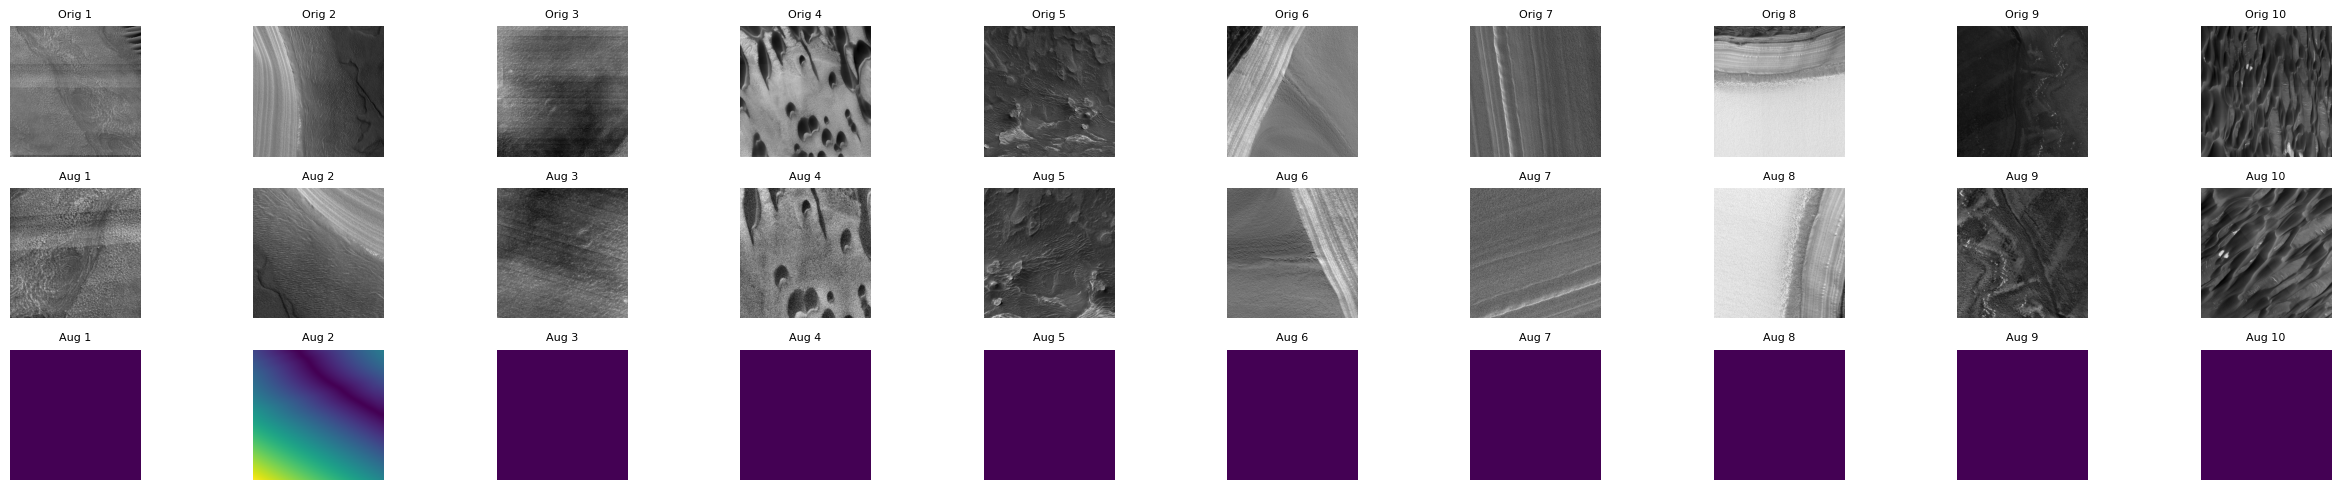

In [7]:
# Example: list of image paths
imIDs = ["p1.jpg", "p2.jpg", "p3.jpg"]
with CONF.TTS_JSON.open() as f:
    TTS = json.load(f)

trainIDs = TTS['0']['full_train']
trainIDs = np.random.choice(trainIDs, size=10, replace=False)

# Store originals & augmentations
to_plot = []

for id in trainIDs:
    # load image → (H, W, C)
    impath = CONF.IMG_DIR / f"{id}.png"
    image = load_png(impath)

    # load mask → (H, W, C)
    maskpath = CONF.MSK_DIR / f"{id}.png"
    mask = load_mask(maskpath, CONF.SEG_CLASSES)

    # load SDM → (H, W, 1)
    sdmpath = CONF.SDM_DIR / f"{id}.npy"
    sdm = load_sdm(sdmpath, mask.shape)

    # # apply transform
    aug = train_transform(image=image, mask=mask, sdm=sdm)
    aug_img, aug_mask, aug_sdm = aug["image"], aug["mask"], aug["sdm"]

    to_plot.append((image, aug_img, aug_sdm))
    

# --- plot in 2 rows x 10 columns ---
fig, axes = plt.subplots(3, 10, figsize=(25, 5))

for i in range(10):
    # top row: originals
    axes[0, i].imshow(to_plot[i][0], cmap='gray')
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Orig {i+1}", fontsize=8)

    # middle row: augmented
    axes[1, i].imshow(to_plot[i][1], cmap='gray')
    axes[1, i].axis("off")
    axes[1, i].set_title(f"Aug {i+1}", fontsize=8)
    
    # bottom row: augmented smds
    axes[2, i].imshow(to_plot[i][2], cmap='viridis')
    axes[2, i].axis("off")
    axes[2, i].set_title(f"Aug {i+1}", fontsize=8)
    
plt.tight_layout()